In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import xarray as xr
from pathlib import Path
import importlib

# ocean_analysis.py in OGGCM/scripts
NB_DIR = Path.cwd()
OCEAN_SCRIPT_DIR = NB_DIR.parents[1] / "OGCM" / "scripts"
if str(OCEAN_SCRIPT_DIR) not in sys.path:
    sys.path.append(str(OCEAN_SCRIPT_DIR))

import ocean_analysis as oa
importlib.reload(oa)

<module 'ocean_analysis' from 'c:\\Users\\Jelle Gortemaker\\Documents\\Thesis\\OGCM\\scripts\\ocean_analysis.py'>

<xarray.Dataset> Size: 235MB
Dimensions:      (Zmd000002: 2, T: 28, Y: 512, Xp1: 513, Yp1: 513, X: 512,
                  Zld000002: 2)
Coordinates:
  * T            (T) float64 224B 0.0 4.32e+04 8.64e+04 ... 1.123e+06 1.166e+06
  * Y            (Y) float64 4kB 250.0 750.0 1.25e+03 ... 2.552e+05 2.558e+05
  * Xp1          (Xp1) float64 4kB 0.0 500.0 1e+03 ... 2.555e+05 2.56e+05
  * Yp1          (Yp1) float64 4kB 0.0 500.0 1e+03 ... 2.555e+05 2.56e+05
  * X            (X) float64 4kB 250.0 750.0 1.25e+03 ... 2.552e+05 2.558e+05
Dimensions without coordinates: Zmd000002, Zld000002
Data variables:
    diag_levels  (Zmd000002) float64 16B ...
    iter         (T) int32 112B ...
    UVEL         (T, Zmd000002, Y, Xp1) float32 59MB ...
    VVEL         (T, Zmd000002, Yp1, X) float32 59MB ...
    THETA        (T, Zmd000002, Y, X) float32 59MB ...
    WVEL         (T, Zld000002, Y, X) float32 59MB ...
Attributes: (12/18)
    MITgcm_version:  checkpoint69l
    build_user:      jgortemaker
    b

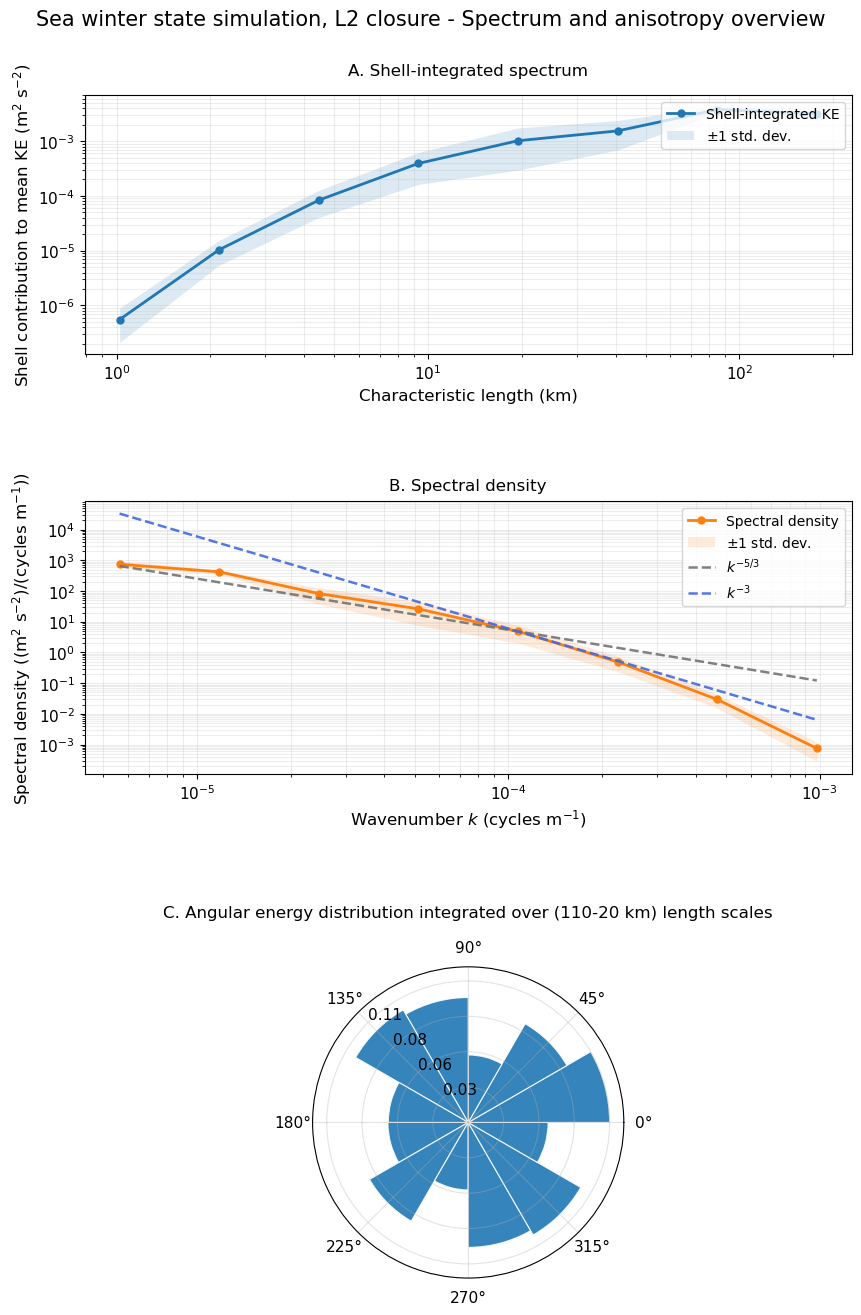

In [21]:
DATA_FILE = (NB_DIR / "../data/input/run_boyd_sea_win_L2.nc").resolve()


eds_init = oa.calculate_EDS_init(
    DATA_FILE,
    target_box=None,
    max_wavelength_km=None,
    x_res=500,
    y_res=500,
    n_bins=8,
    remove_mean=True,
    min_modes_per_bin=3,
    rose_scale_bands_km=[(110, 20)],
    rose_n_angle_bins=12,
    snapshot_index=None,
)

sim_name = "Sea winter state simulation, L2 closure"
if eds_init.attrs['snapshot_time_index'] is not None:
    n_days = eds_init.attrs['snapshot_time_index'] / 2
    title = f"{sim_name} - Spectrum and anisotropy overview (T = {n_days} days)"
else:
    title = f"{sim_name} - Spectrum and anisotropy overview"
oa.plot_eds_overview(eds_init, title=title)


<xarray.Dataset> Size: 294MB
Dimensions:      (Zmd000002: 2, T: 28, Y: 512, Xp1: 513, Yp1: 513, X: 512,
                  Zld000002: 2)
Coordinates:
  * T            (T) float64 224B 2.16e+04 6.48e+04 ... 1.145e+06 1.188e+06
  * Y            (Y) float64 4kB 250.0 750.0 1.25e+03 ... 2.552e+05 2.558e+05
  * Xp1          (Xp1) float64 4kB 0.0 500.0 1e+03 ... 2.555e+05 2.56e+05
  * Yp1          (Yp1) float64 4kB 0.0 500.0 1e+03 ... 2.555e+05 2.56e+05
  * X            (X) float64 4kB 250.0 750.0 1.25e+03 ... 2.552e+05 2.558e+05
Dimensions without coordinates: Zmd000002, Zld000002
Data variables:
    diag_levels  (Zmd000002) float64 16B ...
    iter         (T) int32 112B ...
    UVEL         (T, Zmd000002, Y, Xp1) float32 59MB ...
    VVEL         (T, Zmd000002, Yp1, X) float32 59MB ...
    THETA        (T, Zmd000002, Y, X) float32 59MB ...
    WVEL         (T, Zld000002, Y, X) float32 59MB ...
    momVort3     (T, Zmd000002, Yp1, Xp1) float32 59MB ...
Attributes: (12/18)
    MITgcm_version

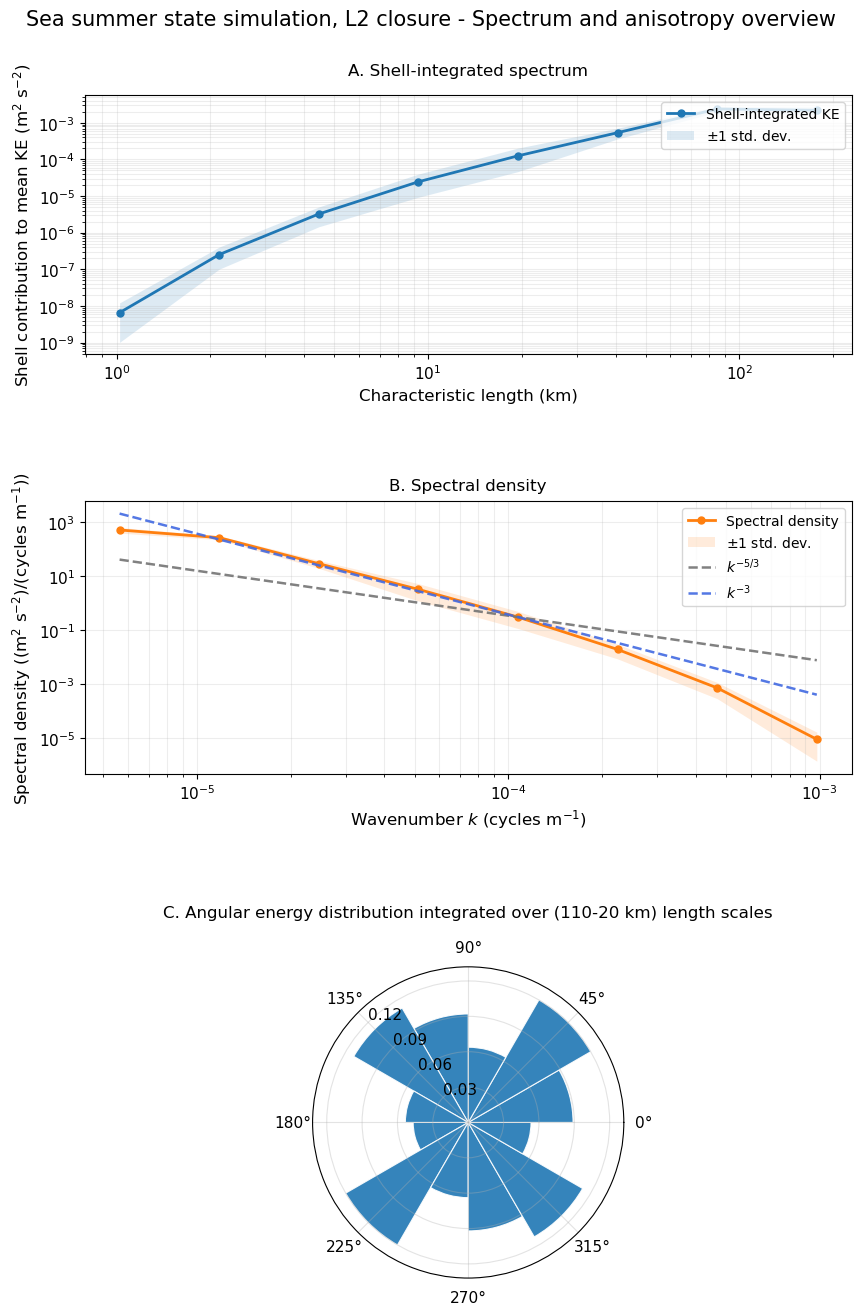

In [22]:
DATA_FILE = (NB_DIR / "../data/input/run_boyd_SGS_L1.nc").resolve()


eds_init = oa.calculate_EDS_init(
    DATA_FILE,
    target_box=None,
    max_wavelength_km=None,
    x_res=500,
    y_res=500,
    n_bins=8,
    remove_mean=True,
    min_modes_per_bin=3,
    rose_scale_bands_km=[(110, 20)],
    rose_n_angle_bins=12,
    snapshot_index=None,
)

sim_name = "Sea summer state simulation, L2 closure"

if eds_init.attrs['snapshot_time_index'] is not None:
    n_days = eds_init.attrs['snapshot_time_index'] / 2
    title = f"{sim_name} - Spectrum and anisotropy overview (T = {n_days} days)"
else:
    title = f"{sim_name} - Spectrum and anisotropy overview"
oa.plot_eds_overview(eds_init, title=title)
